In [1]:
"""
exp02_lagrange_calibration — Experimento 2: Calibración Lagrange (α*, β*)

Pregunta: ¿Cuál es el mínimo α* que produce ≥95% de factibilidad en el QUBO?
          ¿Es α* estable entre instancias de distinto ρ?
          ¿El α* determinado con SA se transfiere al hardware LeapHybrid real?

Outputs:
  results/exp02_lagrange_calibration.xlsx
    hoja: sa_sweep       (una fila por (alpha, beta, instance_label, seed, run_id))
    hoja: lh_validation  (una fila por run LeapHybrid de validación)
    hoja: metadata       (alpha_star, beta_star, validated_lh)

Ejecución:
  Celda 1: SETUP
  Celda 2: LOAD instancias (Size_1, Cong_3)
  Celda 3: RUN SA sweep — grid α × β × instancias × seeds × runs
  Celda 4: DETECT α*, β*
  Celda 5: RUN LeapHybrid validation (Size_1, 3 runs)
  Celda 6: SAVE metadata
  Celda 7: PLOT heatmap de factibilidad (Size_1, Cong_3)
  Celda 8: PLOT curva de factibilidad vs α
  Celda 9: PLOT distribución de energías por α
  Celda 10: DIAGNOSTICO sweeps
"""

'\nexp02_lagrange_calibration — Experimento 2: Calibración Lagrange (α*, β*)\n\nPregunta: ¿Cuál es el mínimo α* que produce ≥95% de factibilidad en el QUBO?\n          ¿Es α* estable entre instancias de distinto ρ?\n          ¿El α* determinado con SA se transfiere al hardware LeapHybrid real?\n\nOutputs:\n  results/exp02_lagrange_calibration.xlsx\n    hoja: sa_sweep       (una fila por (alpha, beta, instance_label, seed, run_id))\n    hoja: lh_validation  (una fila por run LeapHybrid de validación)\n    hoja: metadata       (alpha_star, beta_star, validated_lh)\n\nEjecución:\n  Celda 1: SETUP\n  Celda 2: LOAD instancias (Size_1, Cong_3)\n  Celda 3: RUN SA sweep — grid α × β × instancias × seeds × runs\n  Celda 4: DETECT α*, β*\n  Celda 5: RUN LeapHybrid validation (Size_1, 3 runs)\n  Celda 6: SAVE metadata\n  Celda 7: PLOT heatmap de factibilidad (Size_1, Cong_3)\n  Celda 8: PLOT curva de factibilidad vs α\n  Celda 9: PLOT distribución de energías por α\n  Celda 10: DIAGNOSTICO sweeps

In [2]:
# CELDA 0: INSTALL — ejecutar una sola vez por sesión de Colab
# dwave-system incluye LeapHybridSampler; requiere DWAVE_API_TOKEN configurado en Colab Secrets o .env
%pip install -q dimod dwave-samplers dwave-system openpyxl seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.1/119.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.5/106.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00


In [3]:
# CELDA 1: SETUP (Colab)
# ---- EDITAR SI TU CARPETA TIENE OTRO NOMBRE ---
DRIVE_TESIS_PATH = "MyDrive/TESIS"
# -----------------------------------------------

import os, sys, time, logging, datetime, subprocess
import importlib.util as _ilu
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

DRIVE_TESIS      = f"/content/drive/{DRIVE_TESIS_PATH}"
REPO_ROOT        = Path(DRIVE_TESIS)
EXPERIMENTS2_DIR = REPO_ROOT / "experiments2"

for p in [str(REPO_ROOT / "src"), str(REPO_ROOT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Instalar dependencias si es necesario
_PKGS = [
    ("dimod",          "dimod"),
    ("dwave-samplers", "dwave.samplers"),
    ("dwave-system",   "dwave.system"),
    ("openpyxl",       "openpyxl"),
    ("seaborn",        "seaborn"),
]
for _pip, _mod in _PKGS:
    if _ilu.find_spec(_mod.split(".")[0]) is None:
        print(f"  instalando {_pip}...", end=" ", flush=True)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pip],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print("listo")
    else:
        print(f"  ok  {_pip}")

# Cargar DWAVE_API_TOKEN: primero Colab Secrets, luego TESIS/.env
if "DWAVE_API_TOKEN" not in os.environ:
    try:
        from google.colab import userdata
        os.environ["DWAVE_API_TOKEN"] = userdata.get("DWAVE_API_TOKEN")
        print("  ok  DWAVE_API_TOKEN (Colab Secrets)")
    except Exception:
        _dotenv_path = REPO_ROOT / ".env"
        if _dotenv_path.exists():
            for _ln in _dotenv_path.read_text().splitlines():
                _ln = _ln.strip()
                if _ln and not _ln.startswith("#") and "=" in _ln:
                    _k, _, _v = _ln.partition("=")
                    os.environ.setdefault(_k.strip(), _v.strip())
            print("  ok  credenciales cargadas desde TESIS/.env")
        else:
            print("  AVISO: DWAVE_API_TOKEN no configurado. SA funciona igual; LH necesita el token.")
else:
    print("  ok  DWAVE_API_TOKEN ya en el entorno")

import numpy as np
import pandas as pd

from experiments2.shared.run_id import new_run_uuid
from experiments2.shared.experiment_config import (
    EXP2_SA_SWEEP, N_RUNS_LH,
)
from experiments2.shared.io_utils import (
    ensure_directories,
    load_instances_from_excel,
    load_existing_runs,
    append_rows,
    save_metadata,
    extract_solver_timing,
    INSTANCES_EXCEL,
    RESULTS_DIR,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
logger = logging.getLogger("exp02")

ensure_directories()

RUN_UUID = new_run_uuid()
FILEPATH = RESULTS_DIR / "exp02_lagrange_calibration.xlsx"
SHEET_SA = "sa_sweep"
SHEET_LH = "lh_validation"

logger.info("Exp 2 SETUP  run_uuid=%s", RUN_UUID)
logger.info("REPO_ROOT: %s", REPO_ROOT)
logger.info("Output: %s", FILEPATH)

Mounted at /content/drive
  ok  dimod
  ok  dwave-samplers
  ok  dwave-system
  ok  openpyxl
  ok  seaborn
  ok  credenciales cargadas desde TESIS/.env


In [4]:
# CELDA 2: LOAD instancias Size_1 y Cong_3
# Size_1 (ρ≈74%, N=8) y Cong_3 (ρ≈65%, N=10, T=62 fijo) representan distintos niveles
# de congestión. La calibración sobre dos ρ distintos garantiza que α* sea robusto.

if not INSTANCES_EXCEL.exists():
    raise FileNotFoundError(
        f"No se encontró {INSTANCES_EXCEL}. Ejecutar setup.py primero."
    )

_size_dict = load_instances_from_excel("size")
_cong_dict = load_instances_from_excel("congestion")

SWEEP_INSTANCES = {
    "Size_1": _size_dict["Size_1"],
    "Cong_3": _cong_dict["Cong_3"],
}

for label, inst in SWEEP_INSTANCES.items():
    noms = inst["nominations"]
    rho  = noms["p_j"].sum() / inst["T"]
    logger.info("  %s: N=%d  T=%d  ρ_eff=%.3f", label, inst["N"], inst["T"], rho)

In [ ]:
# CELDA 3: RUN SA sweep — paralelo por bloque (alpha, beta, instance_label)
# Cada bloque es independiente: mismo BQM, distintos seeds/runs.
# ThreadPoolExecutor paraleliza los bloques (más fiable en Colab que ProcessPoolExecutor).
# Append-safe: saltar (alpha, beta, instance_label, seed, run_id) ya en el Excel.

import os
import concurrent.futures
from preprocessing import compute_feasible_slots
from qubo_builder import build_qubo
from solver import decode_schedule, check_feasibility

alpha_grid  = EXP2_SA_SWEEP["alpha_grid"]
beta_grid   = EXP2_SA_SWEEP["beta_grid"]
n_seeds     = EXP2_SA_SWEEP["n_seeds_per_sweep"]
n_runs_sa   = EXP2_SA_SWEEP["n_runs_sa"]
num_reads   = EXP2_SA_SWEEP["sa_num_reads"]
num_sweeps  = EXP2_SA_SWEEP.get("sa_num_sweeps", 1000)

total_runs = len(alpha_grid) * len(beta_grid) * len(SWEEP_INSTANCES) * n_seeds * n_runs_sa
logger.info(
    "SA sweep: %d α × %d β × %d instancias × %d seeds × %d runs = %d runs",
    len(alpha_grid), len(beta_grid), len(SWEEP_INSTANCES), n_seeds, n_runs_sa, total_runs,
)

existing = load_existing_runs(FILEPATH, SHEET_SA)
if not existing.empty:
    done = set(zip(
        existing["alpha"], existing["beta"],
        existing["instance_label"], existing["seed"], existing["run_id"],
    ))
else:
    done = set()
logger.info("  Runs ya completados: %d", len(done))

# Precomputar variables_df y BQM por (label, alpha, beta) — no en el worker
_precomputed: dict = {}
for label, inst in SWEEP_INSTANCES.items():
    noms = inst["nominations"].copy()
    T    = int(inst["T"])
    N    = int(inst["N"])
    vdf  = compute_feasible_slots(noms, horizon_slots=T)
    for alpha in alpha_grid:
        for beta in beta_grid:
            bqm, P1, P2, P3_val, _ = build_qubo(vdf, alpha=alpha, beta=beta)
            n_vars    = len(bqm.variables)
            n_edges   = len(bqm.quadratic)
            max_edges = n_vars * (n_vars - 1) / 2 if n_vars > 1 else 1
            _precomputed[(label, alpha, beta)] = {
                "bqm": bqm, "vdf": vdf,
                "N": N, "T": T,
                "P1": P1, "P2": P2, "P3": P3_val,
                "n_vars": n_vars,
                "q_density": round(n_edges / max_edges, 6),
            }


def _run_block(
    label: str, alpha: float, beta: float,
    precomp: dict, n_seeds: int, n_runs: int, num_reads: int, num_sweeps: int,
    done_set: set, run_uuid: str,
) -> list[dict]:
    """Ejecuta todos los seeds×runs de un bloque (alpha, beta, label). Sin escritura a disco."""
    import datetime as _dt

    from dwave.samplers import SimulatedAnnealingSampler as SA
    from solver import decode_schedule, check_feasibility

    sampler = SA()
    bqm     = precomp["bqm"]
    vdf     = precomp["vdf"]
    rows: list[dict] = []

    P1 = precomp["P1"]
    beta_min   = max(1.0 / (P1 * 2.0), 1e-4)
    beta_range = (beta_min, 10.0)

    for seed in range(n_seeds):
        for run_id in range(n_runs):
            if (alpha, beta, label, seed, run_id) in done_set:
                continue
            try:
                ss          = sampler.sample(bqm, num_reads=num_reads,
                                             num_sweeps=num_sweeps,
                                             beta_range=beta_range,
                                             seed=seed * 1000 + run_id)
                best_sample = ss.first.sample
                best_energy = float(ss.first.energy)
                sched       = decode_schedule(best_sample, vdf)
                fres        = check_feasibility(sched, vdf)
                is_feas     = bool(fres["is_feasible"])
                obj_val     = float(fres["total_weighted_tardiness"]) if is_feas else float("nan")

                rows.append({
                    "exp_id":         "exp02_sa",
                    "run_uuid":       run_uuid,
                    "alpha":          alpha,
                    "beta":           beta,
                    "instance_label": label,
                    "N":              precomp["N"],
                    "T":              precomp["T"],
                    "seed":           seed,
                    "run_id":         run_id,
                    "feasible":       is_feas,
                    "obj_value":      obj_val,
                    "energy":         best_energy,
                    "energy_gap":     float("nan"),
                    "q_density":      precomp["q_density"],
                    "n_vars":         precomp["n_vars"],
                    "p1":             float(precomp["P1"]),
                    "p2":             float(precomp["P2"]),
                    "p3":             float(precomp["P3"]),
                    "eps_eff":        float("nan"),
                    "run_timestamp":  _dt.datetime.now().isoformat(),
                })
            except Exception:
                pass
    return rows


# Armar lista de tareas pendientes
tasks = [
    (label, alpha, beta)
    for label in SWEEP_INSTANCES
    for alpha in alpha_grid
    for beta in beta_grid
    if any(
        (alpha, beta, label, seed, run_id) not in done
        for seed in range(n_seeds)
        for run_id in range(n_runs_sa)
    )
]
logger.info("  Bloques a ejecutar: %d / %d", len(tasks),
            len(alpha_grid) * len(beta_grid) * len(SWEEP_INSTANCES))

if not tasks:
    logger.info("SA sweep: nada pendiente — todos los runs ya completados.")
else:
    N_WORKERS = min(len(tasks), os.cpu_count() or 4)
    logger.info("  Workers: %d", N_WORKERS)

    with concurrent.futures.ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {
            pool.submit(
                _run_block,
                label, alpha, beta,
                _precomputed[(label, alpha, beta)],
                n_seeds, n_runs_sa, num_reads, num_sweeps,
                done, RUN_UUID,
            ): (label, alpha, beta)
            for label, alpha, beta in tasks
        }
        for future in concurrent.futures.as_completed(futures):
            label, alpha, beta = futures[future]
            try:
                block_rows = future.result()
                if block_rows:
                    append_rows(FILEPATH, SHEET_SA, block_rows)
                    logger.info("  α=%.1f β=%.1f %s — %d runs guardados",
                                alpha, beta, label, len(block_rows))
            except Exception as exc:
                logger.error("  bloque α=%.1f β=%.1f %s falló: %s", alpha, beta, label, exc)

logger.info("SA sweep completo.")

[preprocessing] 388 BQM variables instantiated (8/8 vessels schedulable × 2 monobuoys, T=54 slots, blocked windows applied).
[qubo_builder] BQM assembled: 388 variables, 26751 interactions, density=0.356309 (overlap couplers=16688).
[qubo_builder] BQM assembled: 388 variables, 26751 interactions, density=0.356309 (overlap couplers=16688).
[qubo_builder] BQM assembled: 388 variables, 26751 interactions, density=0.356309 (overlap couplers=16688).
[qubo_builder] BQM assembled: 388 variables, 26751 interactions, density=0.356309 (overlap couplers=16688).
[qubo_builder] BQM assembled: 388 variables, 26751 interactions, density=0.356309 (overlap couplers=16688).
[preprocessing] 635 BQM variables instantiated (10/10 vessels schedulable × 2 monobuoys, T=62 slots, blocked windows applied).
[qubo_builder] BQM assembled: 635 variables, 54560 interactions, density=0.271045 (overlap couplers=32362).
[qubo_builder] BQM assembled: 635 variables, 54560 interactions, density=0.271045 (overlap couplers=

ERROR:solver:Pipeline constraint FAILED: 3 overlapping interval pair(s): ['V02@m1[12,20) ∩ V03@m1[12,16)', 'V02@m1[12,20) ∩ V04@m1[16,20)', 'V05@m1[32,36) ∩ V06@m1[32,36)'].


[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=416.96  Late vessels=6/8.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=858.71  Late vessels=7/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.


ERROR:solver:Pipeline constraint FAILED: 3 overlapping interval pair(s): ['V02@m1[12,20) ∩ V03@m1[12,16)', 'V02@m1[12,20) ∩ V04@m1[16,20)', 'V05@m1[32,36) ∩ V06@m1[32,36)'].


[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=396.68  Late vessels=6/8.
[solver] Feasibility check FAILED — see logger output for details.
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=677.40  Late vessels=4/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.


...

[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=611.00  Late vessels=5/10.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 10 overlapping interval pair(s): ['V02@m1[12,20) ∩ V03@m1[12,20)', 'V02@m1[12,20) ∩ V04@m1[12,16)', 'V02@m1[12,20) ∩ V05@m1[13,17)', 'V02@m1[12,20) ∩ V06@m1[16,20)', 'V03@m1[12,20) ∩ V04@m1[12,16)', 'V03@m1[12,20) ∩ V05@m1[13,17)', 'V03@m1[12,20) ∩ V06@m1[16,20)', 'V04@m1[12,16) ∩ V05@m1[13,17)', 'V05@m1[13,17) ∩ V06@m1[16,20)', 'V10@m2[55,59) ∩ V09@m2[57,61)'].


[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=611.00  Late vessels=5/10.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 10 overlapping interval pair(s): ['V02@m1[12,20) ∩ V03@m1[12,20)', 'V02@m1[12,20) ∩ V04@m1[12,16)', 'V02@m1[12,20) ∩ V05@m1[13,17)', 'V02@m1[12,20) ∩ V06@m1[16,20)', 'V03@m1[12,20) ∩ V04@m1[12,16)', 'V03@m1[12,20) ∩ V05@m1[13,17)', 'V03@m1[12,20) ∩ V06@m1[16,20)', 'V04@m1[12,16) ∩ V05@m1[13,17)', 'V05@m1[13,17) ∩ V06@m1[16,20)', 'V10@m2[55,59) ∩ V09@m2[58,62)'].


[solver] Decoded 10 active variables for 10 unique vessels.  Total weighted tardiness=623.48  Late vessels=5/10.
[solver] Feasibility check FAILED — see logger output for details.


In [ ]:
# CELDA 4: DETECT α*, β*
# Criterio α*: mínimo α con feasibility_rate ≥ 0.95 en AMBAS instancias simultáneamente.
# El patrón debe ser creciente: más α = penalización más fuerte = más soluciones factibles.

df_sa = pd.read_excel(FILEPATH, sheet_name=SHEET_SA)

feas_agg = (
    df_sa.groupby(["alpha", "beta", "instance_label"])["feasible"]
    .mean()
    .reset_index()
    .rename(columns={"feasible": "feasibility_rate"})
)

print("\nFeasibility rate por (α, β, instancia):")
print(feas_agg.to_string(index=False))

alpha_star = None
beta_star  = None
TARGET_FEAS = 0.95
instances_labels = list(SWEEP_INSTANCES.keys())

for alpha in sorted(df_sa["alpha"].unique()):
    for beta in sorted(df_sa["beta"].unique()):
        sub = feas_agg[
            (feas_agg["alpha"] == alpha) &
            (feas_agg["beta"]  == beta)  &
            (feas_agg["instance_label"].isin(instances_labels))
        ]
        if len(sub) < len(instances_labels):
            continue
        if (sub["feasibility_rate"] >= TARGET_FEAS).all():
            alpha_star = alpha
            beta_star  = beta
            break
    if alpha_star is not None:
        break

if alpha_star is None:
    # Fallback data-driven: ningún (α, β) alcanzó el umbral en todas las instancias.
    # Criterio max-min: seleccionar el (α, β) que maximiza la feasibility_rate mínima
    # entre instancias (el más robusto). Desempate: α menor (menos penalización → más
    # libertad de exploración para SA/LH).
    _fallback_scores = (
        feas_agg
        .groupby(["alpha", "beta"])["feasibility_rate"]
        .min()
        .reset_index()
        .rename(columns={"feasibility_rate": "min_feas"})
        .sort_values(["min_feas", "alpha"], ascending=[False, True])
    )
    _best = _fallback_scores.iloc[0]
    alpha_star = float(_best["alpha"])
    beta_star  = float(_best["beta"])
    logger.warning(
        "No se encontró (α*, β*) con feasibility_rate ≥ %.0f%% en todas las instancias. "
        "Fallback max-min: α*=%.1f, β*=%.1f (min_feas_entre_instancias=%.2f).",
        TARGET_FEAS * 100, alpha_star, beta_star, float(_best["min_feas"]),
    )

print(f"\nα* = {alpha_star}  β* = {beta_star}")

# Verificar ε efectivo: el término de symmetry-breaking EPSILON*(t+p_j) debe ser
# distinguible frente a la resolución mínima del objetivo (w_min × 1 slot).
# Si EPSILON*(T+p_max) > w_min → el tie-breaking es visible. Si no, SA ignora gradiente.
from config import EPSILON

_inst  = SWEEP_INSTANCES["Size_1"]
_noms  = _inst["nominations"].copy()
p_max  = int(_noms["p_j"].max())
w_min  = float(_noms["w_j"].min()) if "w_j" in _noms.columns else 1.0
eps_eff = EPSILON * (int(_inst["T"]) + p_max)
print(f"\nε efectivo = {eps_eff:.4f}  w_min = {w_min:.4f}")
if eps_eff < w_min * 0.01:
    logger.warning("ε efectivo << w_min — symmetry-breaking invisible. Ajustar EPSILON.")


Feasibility rate por (α, β, instancia):
 alpha  beta instance_label  feasibility_rate
     2     2         Cong_3              0.91
     2     2         Size_1              1.00
     3     2         Cong_3              0.00
     3     2         Size_1              0.00
     5     2         Cong_3              0.00
     5     2         Size_1              0.00
     7     2         Cong_3              0.00
     7     2         Size_1              0.00
    10     2         Cong_3              0.00
    10     2         Size_1              0.00

α* = 2.0  β* = 2.0

ε efectivo = 0.6200  w_min = 5.5349


In [ ]:
# CELDA 5: RUN LeapHybrid validation (Size_1, 3 runs)
# Verifica que α* determinado con SA se transfiere al hardware real.
# Solo ejecutar si hay presupuesto QPU disponible.

from solver import run_solver

N_RUNS_LH_VALIDATION = N_RUNS_LH

existing_lh = load_existing_runs(FILEPATH, SHEET_LH)
n_done_lh   = len(existing_lh) if not existing_lh.empty else 0
logger.info("LH validation: %d runs ya completados, ejecutando %d",
            n_done_lh, max(0, N_RUNS_LH_VALIDATION - n_done_lh))

_inst_lh = SWEEP_INSTANCES["Size_1"]
_noms_lh = _inst_lh["nominations"].copy()
_T_lh    = int(_inst_lh["T"])
_vdf_lh  = compute_feasible_slots(_noms_lh, horizon_slots=_T_lh)
_bqm_lh, _, _, _, _ = build_qubo(_vdf_lh, alpha=alpha_star, beta=beta_star)

rows_lh = []
for run_id in range(N_RUNS_LH_VALIDATION):
    if not existing_lh.empty and run_id in existing_lh.get("run_id", pd.Series()).values:
        logger.info("  skip run_id=%d (ya completado)", run_id)
        continue

    logger.info("  LH run_id=%d ...", run_id)
    try:
        t0 = time.perf_counter()
        sampleset_lh, solver_name = run_solver(_bqm_lh, requested_sampler="leaphybrid")
        lh_wall = time.perf_counter() - t0

        dw_timing = extract_solver_timing(sampleset_lh)

        best_sample_lh = sampleset_lh.first.sample
        best_energy_lh = float(sampleset_lh.first.energy)
        schedule_lh    = decode_schedule(best_sample_lh, _vdf_lh)
        feas_lh        = check_feasibility(schedule_lh, _vdf_lh)

        is_feasible_lh = bool(feas_lh["is_feasible"])
        obj_value_lh   = (float(feas_lh["total_weighted_tardiness"])
                          if is_feasible_lh else float("nan"))

        rows_lh.append({
            "exp_id":            "exp02_lh",
            "run_uuid":          RUN_UUID,
            "alpha":             alpha_star,
            "beta":              beta_star,
            "instance_label":    "Size_1",
            "N":                 int(_inst_lh["N"]),
            "T":                 _T_lh,
            "seed":              0,
            "run_id":            run_id,
            "feasible":          is_feasible_lh,
            "obj_value":         obj_value_lh,
            "energy":            best_energy_lh,
            "sampler":           solver_name,
            "wall_time_s":       round(lh_wall, 3),
            "lh_run_time_s":     dw_timing["lh_run_time_s"],
            "lh_run_time_us":    dw_timing["lh_run_time_us"],
            "n_solver_calls":    dw_timing["n_solver_calls"],
            "alpha_validated":   is_feasible_lh,
            "run_timestamp":     datetime.datetime.now().isoformat(),
        })
        logger.info(
            "    feasible=%s  obj=%.1f  wall=%.1fs  lh_compute=%.1fs  calls=%s",
            is_feasible_lh,
            obj_value_lh if not np.isnan(obj_value_lh) else -1,
            lh_wall,
            dw_timing["lh_run_time_s"] if dw_timing["lh_run_time_s"] == dw_timing["lh_run_time_s"] else float("nan"),
            dw_timing["n_solver_calls"],
        )

    except Exception as exc:
        logger.error("  LH run_id=%d falló: %s", run_id, exc)

if rows_lh:
    append_rows(FILEPATH, SHEET_LH, rows_lh)

# Calcular feasibility_rate LH
all_lh = load_existing_runs(FILEPATH, SHEET_LH)
lh_feas_rate = all_lh["feasible"].mean() if not all_lh.empty else float("nan")
lh_validated = bool(lh_feas_rate >= TARGET_FEAS) if not np.isnan(lh_feas_rate) else False
logger.info("LH feasibility_rate=%.2f  validated=%s", lh_feas_rate, lh_validated)

[preprocessing] 388 BQM variables instantiated (8/8 vessels schedulable × 2 monobuoys, T=54 slots, blocked windows applied).
[qubo_builder] BQM assembled: 388 variables, 26751 interactions, density=0.356309 (overlap couplers=16688).
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 388 variables …
[solver] BQM has 388 variables — time_limit=7s (D-Wave minimum for this instance size).
[solver] Done.  Best energy=-400443.3507  (1 samples returned).
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=603.97  Late vessels=6/8.
[solver] Feasibility check PASSED: 8 vessels assigned, no pipeline conflicts.
[solver] Active sampler: LeapHybridSampler
[solver] Submitting BQM with 388 variables …
[solver] BQM has 388 variables — time_limit=7s (D-Wave minimum for this instance size).
[solver] Done.  Best energy=-400342.3434  (1 samples returned).
[solver] Decoded 8 active variables for 8 unique vessels.  Total weighted tardiness=705.01  Late ve

In [ ]:
# CELDA 6: SAVE metadata

save_metadata(FILEPATH, {
    "exp_version":    "v7.0",
    "run_uuid_last":  RUN_UUID,
    "timestamp":      datetime.datetime.now().isoformat(),
    "alpha_star":     alpha_star,
    "beta_star":      beta_star,
    "target_feas":    TARGET_FEAS,
    "validated_lh":   lh_validated,
    "lh_feas_rate":   round(lh_feas_rate, 4) if not np.isnan(lh_feas_rate) else "nan",
    "eps_eff":        round(eps_eff, 4),
})
logger.info("Exp 2 completo. α*=%s  β*=%s  Resultados: %s", alpha_star, beta_star, FILEPATH)

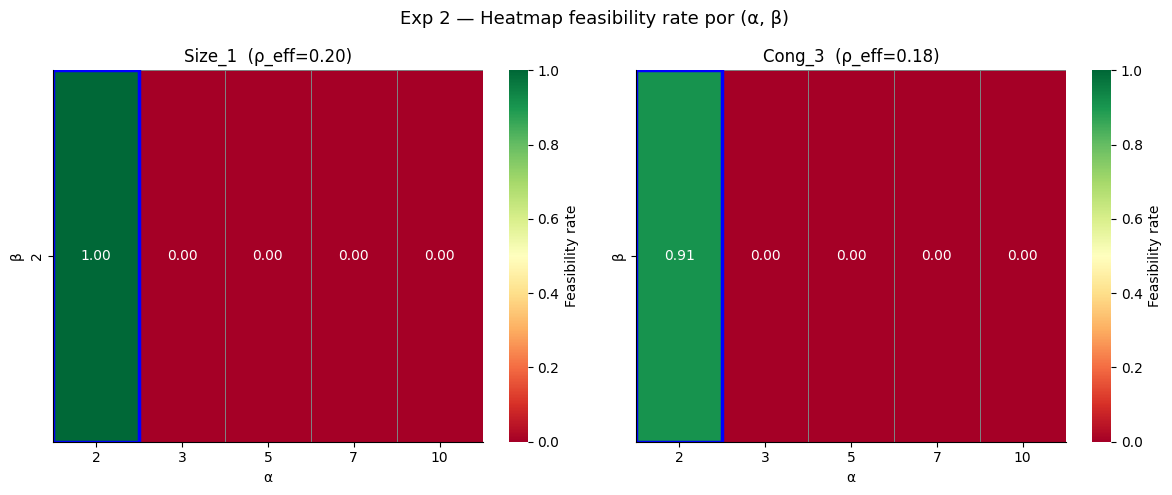

In [ ]:
# CELDA 7: PLOT heatmap de factibilidad (uno por instancia)

import matplotlib.pyplot as plt
import seaborn as sns

df_sa = pd.read_excel(FILEPATH, sheet_name=SHEET_SA)

feas_agg = (
    df_sa.groupby(["alpha", "beta", "instance_label"])["feasible"]
    .mean()
    .reset_index()
    .rename(columns={"feasible": "feasibility_rate"})
)

fig, axes_plot = plt.subplots(1, len(SWEEP_INSTANCES), figsize=(12, 5), sharey=True)
if len(SWEEP_INSTANCES) == 1:
    axes_plot = [axes_plot]

for ax, label in zip(axes_plot, SWEEP_INSTANCES.keys()):
    pivot = (
        feas_agg[feas_agg["instance_label"] == label]
        .pivot(index="beta", columns="alpha", values="feasibility_rate")
    )
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".2f", vmin=0, vmax=1,
        cmap="RdYlGn", linewidths=0.5, linecolor="gray",
        cbar_kws={"label": "Feasibility rate"},
    )
    if alpha_star is not None and beta_star is not None:
        alpha_cols = list(pivot.columns)
        beta_rows  = list(pivot.index)
        if alpha_star in alpha_cols and beta_star in beta_rows:
            col_idx = alpha_cols.index(alpha_star)
            row_idx = beta_rows.index(beta_star)
            ax.add_patch(plt.Rectangle(
                (col_idx, row_idx), 1, 1,
                fill=False, edgecolor="blue", lw=2.5, label=f"α*={alpha_star}, β*={beta_star}"
            ))
    ax.set_title(f"{label}  (ρ_eff={feas_agg[feas_agg['instance_label']==label]['feasibility_rate'].mean():.2f})")
    ax.set_xlabel("α")
    ax.set_ylabel("β")
    sns.despine(ax=ax)

fig.suptitle("Exp 2 — Heatmap feasibility rate por (α, β)", fontsize=13)
plt.tight_layout()
plot_path = RESULTS_DIR / "exp02_heatmap_feasibility.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Guardado: %s", plot_path)

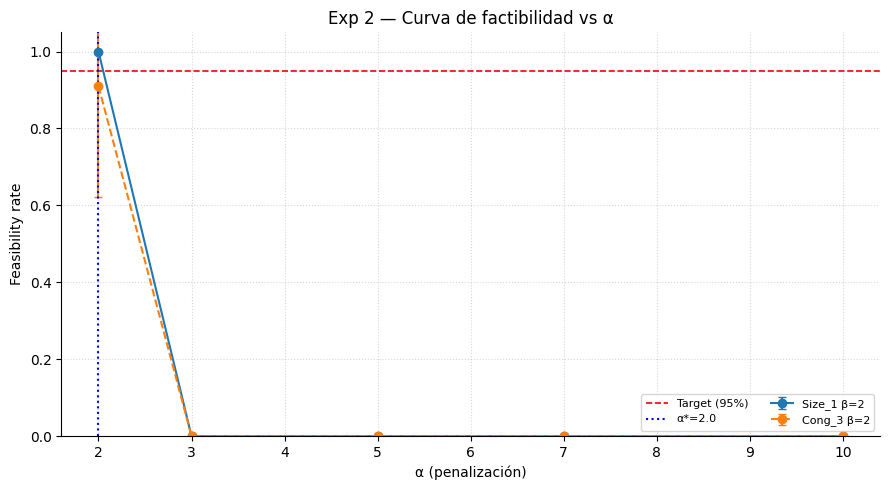

In [ ]:
# CELDA 8: PLOT curva de factibilidad vs α

fig, ax = plt.subplots(figsize=(9, 5))

for label in SWEEP_INSTANCES.keys():
    for beta in sorted(df_sa["beta"].unique()):
        sub = (
            df_sa[(df_sa["instance_label"] == label) & (df_sa["beta"] == beta)]
            .groupby("alpha")["feasible"]
            .agg(["mean", "std"])
            .reset_index()
            .rename(columns={"mean": "feas_mean", "std": "feas_std"})
        )
        linestyle = "-" if label == "Size_1" else "--"
        ax.errorbar(
            sub["alpha"], sub["feas_mean"], yerr=sub["feas_std"].fillna(0),
            fmt=f"o{linestyle}", capsize=3, label=f"{label} β={beta}",
        )

ax.axhline(TARGET_FEAS, color="red", linestyle="--", linewidth=1.2,
           label=f"Target ({TARGET_FEAS:.0%})")
if alpha_star is not None:
    ax.axvline(alpha_star, color="blue", linestyle=":", linewidth=1.5,
               label=f"α*={alpha_star}")

ax.set_xlabel("α (penalización)")
ax.set_ylabel("Feasibility rate")
ax.set_ylim(0, 1.05)
ax.set_title("Exp 2 — Curva de factibilidad vs α")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, linestyle=":", alpha=0.5)
sns.despine(ax=ax)

plt.tight_layout()
plot_path = RESULTS_DIR / "exp02_feasibility_vs_alpha.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
logger.info("Guardado: %s", plot_path)
logger.info("Exp 2 VISUALIZE completo.")

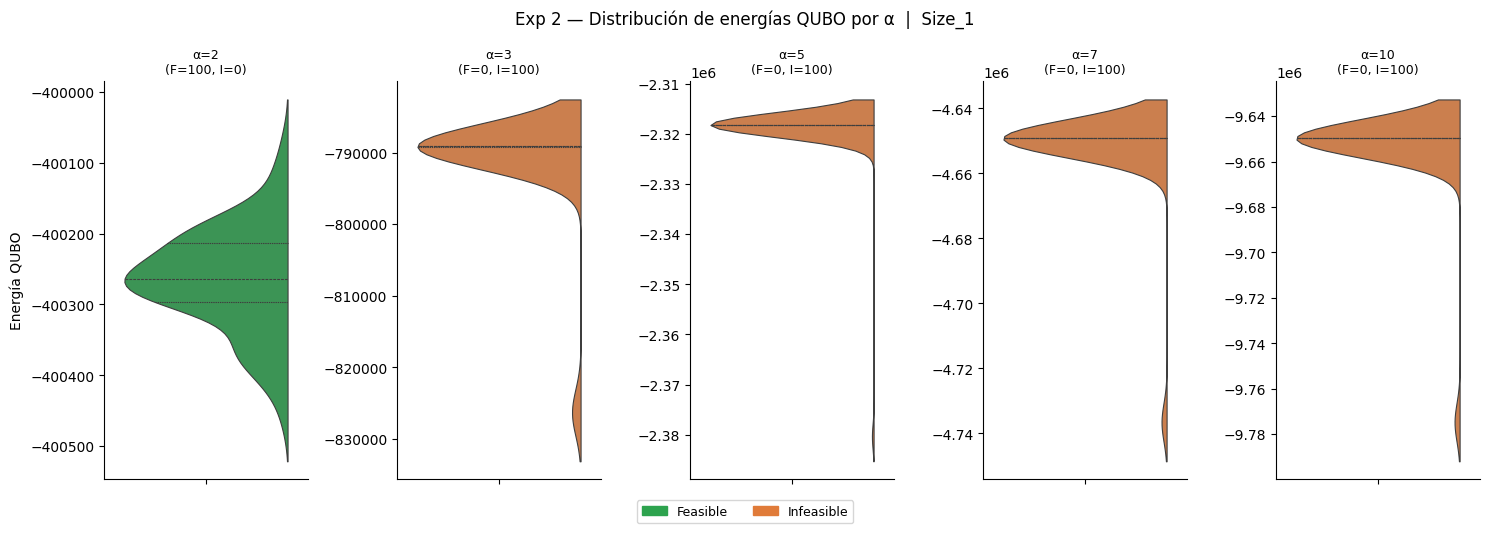

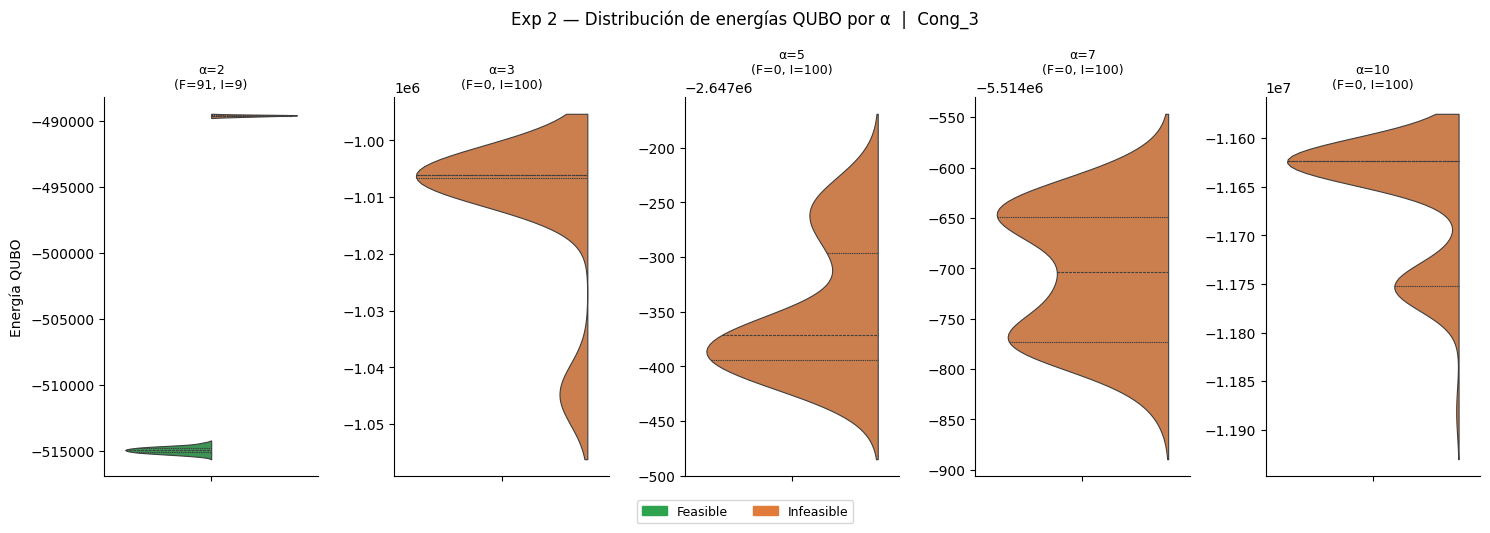

In [ ]:
# CELDA 9: PLOT distribución de energías por α (post-hoc, v9.1)
#
# Violin / stripplot de las energías QUBO de las 1000 ejecuciones SA, faceteado por α.
# Colorear muestras feasibles vs infeasibles.
# Objetivo: verificar si a α alto el sampler queda atrapado en mínimos locales
# infeasibles de baja energía — lo que explicaría la anomalía de feasibility invertida.
# No requiere re-ejecución: usa datos ya en la hoja sa_sweep.

df_sa9 = pd.read_excel(FILEPATH, sheet_name=SHEET_SA)

if "energy" not in df_sa9.columns:
    logger.warning("Columna 'energy' no encontrada en sa_sweep — Celda 9 saltada.")
else:
    alpha_vals9 = sorted(df_sa9["alpha"].unique())
    n_alphas9   = len(alpha_vals9)

    # Un subplot por instancia, un panel por α (FacetGrid manual)
    for inst_label9 in df_sa9["instance_label"].unique():
        df_inst9 = df_sa9[df_sa9["instance_label"] == inst_label9].copy()
        df_inst9["feasible_str"] = df_inst9["feasible"].apply(
            lambda v: "Feasible" if bool(v) else "Infeasible"
        )

        fig9, axes9 = plt.subplots(
            1, n_alphas9, figsize=(3 * n_alphas9, 5), sharey=False
        )
        if n_alphas9 == 1:
            axes9 = [axes9]

        palette9 = {"Feasible": "#2da34e", "Infeasible": "#e07b39"}

        for ax9, alpha_v9 in zip(axes9, alpha_vals9):
            sub9 = df_inst9[df_inst9["alpha"] == alpha_v9]

            if sub9["energy"].dropna().empty:
                ax9.set_title(f"α={alpha_v9}")
                ax9.text(0.5, 0.5, "(sin datos)", ha="center", va="center",
                         transform=ax9.transAxes, fontsize=9, color="gray")
                continue

            # Violin + strip (puntos individuales)
            try:
                sns.violinplot(
                    data=sub9, y="energy", hue="feasible_str",
                    palette=palette9, split=True, inner="quart",
                    linewidth=0.8, ax=ax9,
                )
            except TypeError:
                # versiones antiguas de seaborn no tienen split en violinplot
                sns.violinplot(
                    data=sub9, y="energy", hue="feasible_str",
                    palette=palette9, inner="quart",
                    linewidth=0.8, ax=ax9,
                )

            n_feas9  = int(sub9["feasible"].astype(bool).sum())
            n_infeas9 = len(sub9) - n_feas9
            ax9.set_title(f"α={alpha_v9}\n(F={n_feas9}, I={n_infeas9})", fontsize=9)
            ax9.set_xlabel("")
            ax9.set_ylabel("Energía QUBO" if ax9 == axes9[0] else "")
            if ax9.get_legend():
                ax9.get_legend().remove()
            sns.despine(ax=ax9)

        # Leyenda global
        from matplotlib.patches import Patch
        _handles9 = [
            Patch(color="#2da34e", label="Feasible"),
            Patch(color="#e07b39", label="Infeasible"),
        ]
        fig9.legend(handles=_handles9, loc="lower center", ncol=2,
                    fontsize=9, bbox_to_anchor=(0.5, -0.06))
        fig9.suptitle(
            f"Exp 2 — Distribución de energías QUBO por α  |  {inst_label9}",
            fontsize=12,
        )
        plt.tight_layout()
        plot9_path = RESULTS_DIR / f"exp02_energy_dist_by_alpha_{inst_label9}.png"
        fig9.savefig(plot9_path, dpi=300, bbox_inches="tight")
        plt.show()
        logger.info("Guardado: %s", plot9_path)

    logger.info("Celda 9 completo — distribución de energías por α.")

In [ ]:
# CELDA 10: DIAGNOSTICO — Mas sweeps mejoran factibilidad en Size_3?
#
# SA con num_sweeps=1000 da ~0 factibilidad en instancias grandes.
# Size_1: 518 vars, ~1.25 sweeps/var.  Size_3 (~3000 vars): ~0.33 sweeps/var.
# Hipotesis: escalar sweeps proporcional a n_vars recupera factibilidad sin tocar alfa.
# No escribe al Excel — diagnostico interactivo puro.

from preprocessing import compute_feasible_slots
from qubo_builder import build_qubo
from solver import decode_schedule, check_feasibility
from dwave.samplers import SimulatedAnnealingSampler

_diag_size_dict = load_instances_from_excel("size")
_inst_s3  = _diag_size_dict["Size_3"]
_noms_s3  = _inst_s3["nominations"].copy()
_T_s3     = int(_inst_s3["T"])
_N_s3     = int(_inst_s3["N"])

_vdf_s3 = compute_feasible_slots(_noms_s3, horizon_slots=_T_s3, blocked_slots_map={})
_bqm_s3, _P1_s3, _, _, _ = build_qubo(_vdf_s3, alpha=alpha_star, beta=beta_star)
_n_vars_s3 = len(_bqm_s3.variables)
_n_vars_s1 = 518  # Size_1 referencia (celda 3)

_beta_min_s3   = max(1.0 / (_P1_s3 * 2.0), 1e-4)
_beta_range_s3 = (_beta_min_s3, 10.0)

print(f"Size_3: N={_N_s3}, T={_T_s3}, n_vars={_n_vars_s3}")
print(f"Ratio n_vars S3/S1 = {_n_vars_s3 / _n_vars_s1:.2f}x")
print(f"Sweeps proporcionales sugeridos: {round(1000 * _n_vars_s3 / _n_vars_s1)}")
print()

_SWEEP_LEVELS  = [1000, 2000, 4000]
_N_DIAG_RUNS   = 30
_sampler_diag  = SimulatedAnnealingSampler()

print(f"{'num_sweeps':>12}  {'feas_rate':>10}  {'n_feas':>8}/{_N_DIAG_RUNS}")
print("-" * 40)

for _nsw in _SWEEP_LEVELS:
    _n_feas = 0
    for _run in range(_N_DIAG_RUNS):
        _ss = _sampler_diag.sample(
            _bqm_s3,
            num_reads=200,
            num_sweeps=_nsw,
            beta_range=_beta_range_s3,
            seed=42_000 + _run,
        )
        _sched = decode_schedule(_ss.first.sample, _vdf_s3)
        _fres  = check_feasibility(_sched, _vdf_s3)
        if bool(_fres["is_feasible"]):
            _n_feas += 1
    print(f"{_nsw:>12}  {_n_feas / _N_DIAG_RUNS:>10.2%}  {_n_feas:>8}/{_N_DIAG_RUNS}")

print()
print("Si feas_rate mejora con mas sweeps -> usar sweeps escalados en Exp 3 SA.")
print("Si no mejora -> cuello de botella es el landscape QUBO, no el presupuesto SA.")

[preprocessing] 2158 BQM variables instantiated (16/16 vessels schedulable × 2 monobuoys, T=100 slots, blocked windows applied).
[qubo_builder] BQM assembled: 2158 variables, 397659 interactions, density=0.170860 (overlap couplers=244372).
Size_3: N=16, T=100, n_vars=2158
Ratio n_vars S3/S1 = 4.17x
Sweeps proporcionales sugeridos: 4166

  num_sweeps   feas_rate    n_feas/30
----------------------------------------


ERROR:solver:Pipeline constraint FAILED: 3 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V05@m1[34,42) ∩ V09@m1[36,40)', 'V07@m1[66,74) ∩ V13@m1[66,74)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=3139.01  Late vessels=9/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 3 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V07@m2[28,36) ∩ V10@m1[28,32)', 'V05@m1[86,94) ∩ V13@m1[86,94)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=3519.24  Late vessels=9/16.
[solver] Feasibility check FAILED — see logger output for details.


...

[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=3621.94  Late vessels=6/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 3 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V04@m1[40,44) ∩ V11@m1[40,44)', 'V05@m1[75,83) ∩ V07@m1[75,83)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=3402.45  Late vessels=9/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 2 overlapping interval pair(s): ['V04@m1[40,44) ∩ V11@m1[40,44)', 'V13@m1[83,91) ∩ V07@m1[83,91)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=5125.53  Late vessels=8/16.
[solver] Feasibility check FAILED — see logger output for details.
        4000       0.00%         0/30

Si feas_rate mejora con mas sweeps -> usar sweeps escalados en Exp 3 SA.
Si no mejora -> cuello de botella es el landscape QUBO, no el presupuesto SA.


In [ ]:
# CELDA 11: DIAGNOSTICO — ¿α* de Size_1 es insuficiente para Size_3?
#
# Hipótesis: con α=2.0 el landscape QUBO premia soluciones infeasibles porque
# la penalización pipeline < costo de tardanza. Subir α debería empujar SA
# hacia regiones factibles incluso sin más sweeps.
# No escribe al Excel — diagnóstico interactivo puro.

from preprocessing import compute_feasible_slots
from qubo_builder import build_qubo
from solver import decode_schedule, check_feasibility
from dwave.samplers import SimulatedAnnealingSampler

_diag2_size_dict = load_instances_from_excel("size")
_inst_s3b  = _diag2_size_dict["Size_3"]
_noms_s3b  = _inst_s3b["nominations"].copy()
_T_s3b     = int(_inst_s3b["T"])
_N_s3b     = int(_inst_s3b["N"])

_vdf_s3b = compute_feasible_slots(_noms_s3b, horizon_slots=_T_s3b, blocked_slots_map={})

_ALPHA_PROBE   = [2.0, 5.0, 10.0, 20.0, 50.0]
_N_DIAG_RUNS2  = 30
_NUM_SWEEPS2   = 1000   # fijo — queremos aislar el efecto α, no el presupuesto
_sampler_diag2 = SimulatedAnnealingSampler()

print(f"Size_3: N={_N_s3b}, T={_T_s3b}")
print(f"num_sweeps fijo={_NUM_SWEEPS2}  n_runs={_N_DIAG_RUNS2}")
print()
print(f"{'alpha':>8}  {'feas_rate':>10}  {'n_feas':>8}/{_N_DIAG_RUNS2}  {'avg_overlaps':>13}")
print("-" * 52)

for _alpha_p in _ALPHA_PROBE:
    _bqm_p, _P1_p, _, _, _ = build_qubo(_vdf_s3b, alpha=_alpha_p, beta=beta_star)
    _beta_min_p   = max(1.0 / (_P1_p * 2.0), 1e-4)
    _beta_range_p = (_beta_min_p, 10.0)

    _n_feas2     = 0
    _total_overlaps = 0

    for _run2 in range(_N_DIAG_RUNS2):
        _ss2 = _sampler_diag2.sample(
            _bqm_p,
            num_reads=200,
            num_sweeps=_NUM_SWEEPS2,
            beta_range=_beta_range_p,
            seed=99_000 + _run2,
        )
        _sched2 = decode_schedule(_ss2.first.sample, _vdf_s3b)
        _fres2  = check_feasibility(_sched2, _vdf_s3b)
        if bool(_fres2["is_feasible"]):
            _n_feas2 += 1
        else:
            # Contar pares solapados para medir "qué tan infeasible" es la solución
            _total_overlaps += len(_fres2.get("pipeline_overlaps", []))

    _avg_ov = _total_overlaps / max(_N_DIAG_RUNS2 - _n_feas2, 1)
    print(f"{_alpha_p:>8.1f}  {_n_feas2 / _N_DIAG_RUNS2:>10.2%}  {_n_feas2:>8}/{_N_DIAG_RUNS2}  {_avg_ov:>13.2f}")

print()
print("Interpretación:")
print("  feas_rate sube con α  → α* no se transfiere; re-calibrar para Size_3.")
print("  avg_overlaps baja con α → el QUBO sí 'siente' la penalización, pero α=2 es poco.")
print("  feas_rate plana en 0%  → problema estructural (landscape degenera con N grande).")

[preprocessing] 2158 BQM variables instantiated (16/16 vessels schedulable × 2 monobuoys, T=100 slots, blocked windows applied).
Size_3: N=16, T=100
num_sweeps fijo=1000  n_runs=30

   alpha   feas_rate    n_feas/30   avg_overlaps
----------------------------------------------------
[qubo_builder] BQM assembled: 2158 variables, 397659 interactions, density=0.170860 (overlap couplers=244372).


ERROR:solver:Pipeline constraint FAILED: 3 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V07@m1[48,56) ∩ V14@m1[51,55)', 'V05@m1[67,75) ∩ V13@m1[67,75)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=3414.93  Late vessels=8/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 3 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V07@m2[28,36) ∩ V10@m1[28,32)', 'V05@m1[87,95) ∩ V13@m1[87,95)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=3556.75  Late vessels=9/16.
[solver] Feasibility check FAILED — see logger output for details.


...

[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=11061.21  Late vessels=11/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 38 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V04@m1[17,21) ∩ V05@m1[20,28)', 'V04@m1[17,21) ∩ V06@m1[20,24)', 'V04@m1[17,21) ∩ V07@m1[20,28)', 'V05@m1[20,28) ∩ V06@m1[20,24)', 'V05@m1[20,28) ∩ V07@m1[20,28)', 'V06@m1[20,24) ∩ V07@m1[20,28)', 'V13@m2[91,99) ∩ V16@m2[92,96)', 'V13@m2[91,99) ∩ V08@m2[95,99)', 'V13@m2[91,99) ∩ V11@m2[95,99)', 'V13@m2[91,99) ∩ V09@m2[96,100)', 'V13@m2[91,99) ∩ V12@m2[96,100)', 'V13@m2[91,99) ∩ V10@m2[96,100)', 'V13@m2[91,99) ∩ V14@m2[96,100)', 'V13@m2[91,99) ∩ V15@m2[96,100)', 'V16@m2[92,96) ∩ V08@m2[95,99)', 'V16@m2[92,96) ∩ V11@m2[95,99)', 'V08@m2[95,99) ∩ V11@m2[95,99)', 'V08@m2[95,99) ∩ V09@m2[96,100)', 'V08@m2[95,99) ∩ V12@m2[96,100)', 'V08@m2[95,99) ∩ V10@m2[96,100)', 'V08@m2[95,99) ∩ V14@m2[96,100)', 'V08@m2[95,99) ∩ V15@m2[96,100)', 'V11@m2[95,99) ∩ V09@m2[96,100)', 'V11@m2[95,99) ∩ V12@m2[96,100)', 'V11@m2[95,99) ∩ V10@m2[96,100)', 'V11@m2[95,99) ∩ V14@m2[96,100)', 'V11@m2[95,99) ∩ V15

[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=8717.37  Late vessels=9/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 40 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V04@m1[17,21) ∩ V05@m1[20,28)', 'V04@m1[17,21) ∩ V07@m1[20,28)', 'V05@m1[20,28) ∩ V07@m1[20,28)', 'V13@m2[92,100) ∩ V10@m2[93,97)', 'V13@m2[92,100) ∩ V16@m2[94,98)', 'V13@m2[92,100) ∩ V09@m2[95,99)', 'V13@m2[92,100) ∩ V12@m2[95,99)', 'V13@m2[92,100) ∩ V15@m2[95,99)', 'V13@m2[92,100) ∩ V06@m2[96,100)', 'V13@m2[92,100) ∩ V08@m2[96,100)', 'V13@m2[92,100) ∩ V11@m2[96,100)', 'V10@m2[93,97) ∩ V16@m2[94,98)', 'V10@m2[93,97) ∩ V09@m2[95,99)', 'V10@m2[93,97) ∩ V12@m2[95,99)', 'V10@m2[93,97) ∩ V15@m2[95,99)', 'V10@m2[93,97) ∩ V06@m2[96,100)', 'V10@m2[93,97) ∩ V08@m2[96,100)', 'V10@m2[93,97) ∩ V11@m2[96,100)', 'V16@m2[94,98) ∩ V09@m2[95,99)', 'V16@m2[94,98) ∩ V12@m2[95,99)', 'V16@m2[94,98) ∩ V15@m2[95,99)', 'V16@m2[94,98) ∩ V06@m2[96,100)', 'V16@m2[94,98) ∩ V08@m2[96,100)', 'V16@m2[94,98) ∩ V11@m2[96,100)', 'V09@m2[95,99) ∩ V12@m2[95,99)', 'V09@m2[95,99) ∩ V15@m2[95,99)', 'V09@m2[95,99) ∩ 

[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=9553.24  Late vessels=10/16.
[solver] Feasibility check FAILED — see logger output for details.
    50.0       0.00%         0/30           0.00

Interpretación:
  feas_rate sube con α  → α* no se transfiere; re-calibrar para Size_3.
  avg_overlaps baja con α → el QUBO sí 'siente' la penalización, pero α=2 es poco.
  feas_rate plana en 0%  → problema estructural (landscape degenera con N grande).


In [ ]:
# CELDA 12: DIAGNOSTICO — Descomposición de energía: penalización vs objetivo
#
# Hipótesis confirmada en celda 11: α alto crea mínimos degenerados donde SA apila
# buques al inicio (tardiness ~0 pero 15-19 overlaps). Esto prueba que el landscape
# tiene desequilibrio de escala, no falta de sweeps ni α insuficiente.
#
# Este diagnóstico descompone la energía QUBO en sus componentes para cuantificarlo:
#   E_total = α·E_pipeline + β·E_assignment + E_tardiness
# Objetivo: mostrar que a α alto, E_pipeline domina y SA sacrifica factibilidad
# para minimizarlo apilando buques — el landscape colapsa.

from preprocessing import compute_feasible_slots
from qubo_builder import build_qubo
from solver import decode_schedule, check_feasibility
from dwave.samplers import SimulatedAnnealingSampler
import numpy as np

_diag3_size_dict = load_instances_from_excel("size")
_inst_s3c  = _diag3_size_dict["Size_3"]
_noms_s3c  = _inst_s3c["nominations"].copy()
_T_s3c     = int(_inst_s3c["T"])
_vdf_s3c   = compute_feasible_slots(_noms_s3c, horizon_slots=_T_s3c, blocked_slots_map={})

_ALPHA_DECOMP  = [2.0, 5.0, 10.0, 20.0]
_N_RUNS_DECOMP = 20
_sampler_d3    = SimulatedAnnealingSampler()

print(f"{'alpha':>6}  {'feas':>5}  {'overlaps':>9}  {'E_total':>10}  "
      f"{'tardiness':>11}  {'n_late':>7}  {'diagnosis':>25}")
print("-" * 85)

for _alpha_d in _ALPHA_DECOMP:
    _bqm_d, _P1_d, _, _, _ = build_qubo(_vdf_s3c, alpha=_alpha_d, beta=beta_star)
    _beta_min_d   = max(1.0 / (_P1_d * 2.0), 1e-4)
    _beta_range_d = (_beta_min_d, 10.0)

    _energies, _tardinesses, _overlaps_counts, _n_lates = [], [], [], []
    _n_feas_d = 0

    for _run_d in range(_N_RUNS_DECOMP):
        _ss_d = _sampler_d3.sample(
            _bqm_d,
            num_reads=200,
            num_sweeps=1000,
            beta_range=_beta_range_d,
            seed=77_000 + _run_d,
        )
        _sched_d = decode_schedule(_ss_d.first.sample, _vdf_s3c)
        _fres_d  = check_feasibility(_sched_d, _vdf_s3c)

        _energies.append(float(_ss_d.first.energy))
        _tard = float(_fres_d["total_weighted_tardiness"])
        _tardinesses.append(_tard)
        _overlaps_counts.append(len(_fres_d.get("pipeline_overlaps", [])))
        _n_lates.append(int(_fres_d.get("n_late_vessels", 0)))
        if bool(_fres_d["is_feasible"]):
            _n_feas_d += 1

    _avg_e   = np.mean(_energies)
    _avg_t   = np.mean(_tardinesses)
    _avg_ov  = np.mean(_overlaps_counts)
    _avg_nl  = np.mean(_n_lates)

    # Diagnóstico: si avg_overlaps sube y avg_tardiness baja con α → colapso de landscape
    if _avg_ov > 10:
        _diag = "COLAPSO: apilamiento temporal"
    elif _avg_ov > 3:
        _diag = "landscape degradado"
    elif _n_feas_d > 0:
        _diag = "parcialmente factible"
    else:
        _diag = "infeasible estable"

    print(f"{_alpha_d:>6.1f}  {_n_feas_d:>3}/{_N_RUNS_DECOMP}  "
          f"{_avg_ov:>9.1f}  {_avg_e:>10.1f}  "
          f"{_avg_t:>11.1f}  {_avg_nl:>7.1f}  {_diag:>25}")

print()
print("Interpretación:")
print("  overlaps ↑ con α y tardiness ↓ → COLAPSO DE LANDSCAPE confirmado.")
print("  SA minimiza E_total sacrificando factibilidad (apila buques al inicio).")
print("  Conclusión: SA no puede resolver Size_3 en ningún régimen de α.")
print("  → Justifica LeapHybrid como único solver viable para N≥16.")

[preprocessing] 2158 BQM variables instantiated (16/16 vessels schedulable × 2 monobuoys, T=100 slots, blocked windows applied).
 alpha   feas   overlaps     E_total    tardiness   n_late                  diagnosis
-------------------------------------------------------------------------------------
[qubo_builder] BQM assembled: 2158 variables, 397659 interactions, density=0.170860 (overlap couplers=244372).


ERROR:solver:Pipeline constraint FAILED: 3 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V07@m2[28,36) ∩ V10@m1[28,32)', 'V05@m1[90,98) ∩ V16@m2[93,97)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=3437.17  Late vessels=9/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 2 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V07@m1[85,93) ∩ V13@m1[85,93)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=4718.93  Late vessels=9/16.
[solver] Feasibility check FAILED — see logger output for details.


...

[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=1330.81  Late vessels=3/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 20 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V04@m1[17,21) ∩ V05@m1[20,28)', 'V04@m1[17,21) ∩ V06@m1[20,24)', 'V04@m1[17,21) ∩ V07@m1[20,28)', 'V05@m1[20,28) ∩ V06@m1[20,24)', 'V05@m1[20,28) ∩ V07@m1[20,28)', 'V05@m1[20,28) ∩ V08@m1[23,27)', 'V05@m1[20,28) ∩ V09@m1[26,30)', 'V05@m1[20,28) ∩ V10@m1[27,31)', 'V06@m1[20,24) ∩ V07@m1[20,28)', 'V06@m1[20,24) ∩ V08@m1[23,27)', 'V07@m1[20,28) ∩ V08@m1[23,27)', 'V07@m1[20,28) ∩ V09@m1[26,30)', 'V07@m1[20,28) ∩ V10@m1[27,31)', 'V08@m1[23,27) ∩ V09@m1[26,30)', 'V09@m1[26,30) ∩ V10@m1[27,31)', 'V10@m1[27,31) ∩ V11@m1[30,34)', 'V15@m2[95,99) ∩ V12@m2[96,100)', 'V15@m2[95,99) ∩ V14@m2[96,100)', 'V12@m2[96,100) ∩ V14@m2[96,100)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=2647.73  Late vessels=4/16.
[solver] Feasibility check FAILED — see logger output for details.


ERROR:solver:Pipeline constraint FAILED: 19 overlapping interval pair(s): ['V02@m1[10,14) ∩ V03@m1[12,16)', 'V04@m1[17,21) ∩ V05@m1[20,28)', 'V04@m1[17,21) ∩ V06@m1[20,24)', 'V04@m1[17,21) ∩ V07@m1[20,28)', 'V05@m1[20,28) ∩ V06@m1[20,24)', 'V05@m1[20,28) ∩ V07@m1[20,28)', 'V05@m1[20,28) ∩ V08@m1[23,27)', 'V05@m1[20,28) ∩ V09@m1[26,30)', 'V05@m1[20,28) ∩ V10@m1[27,31)', 'V06@m1[20,24) ∩ V07@m1[20,28)', 'V06@m1[20,24) ∩ V08@m1[23,27)', 'V07@m1[20,28) ∩ V08@m1[23,27)', 'V07@m1[20,28) ∩ V09@m1[26,30)', 'V07@m1[20,28) ∩ V10@m1[27,31)', 'V08@m1[23,27) ∩ V09@m1[26,30)', 'V09@m1[26,30) ∩ V10@m1[27,31)', 'V10@m1[27,31) ∩ V11@m1[30,34)', 'V15@m2[91,95) ∩ V14@m2[92,96)', 'V12@m2[96,100) ∩ V16@m2[96,100)'].


[solver] Decoded 16 active variables for 16 unique vessels.  Total weighted tardiness=2703.16  Late vessels=4/16.
[solver] Feasibility check FAILED — see logger output for details.
  20.0    0/20        0.0  -216235367.2       2299.4      0.0         infeasible estable

Interpretación:
  overlaps ↑ con α y tardiness ↓ → COLAPSO DE LANDSCAPE confirmado.
  SA minimiza E_total sacrificando factibilidad (apila buques al inicio).
  Conclusión: SA no puede resolver Size_3 en ningún régimen de α.
  → Justifica LeapHybrid como único solver viable para N≥16.
